<a href="https://colab.research.google.com/github/Alok-Senapati/Masai-IITP-AIML-Assignments/blob/main/Assignment14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
transactions = pd.DataFrame({
    'transaction_id': ['T01','T02','T03','T04','T05','T06','T07','T08'],
    'store_id': ['S1','S2','S1','S3','S2','S1','S3','S2'],
    'product_id': ['P1','P2','P3','P1','P2','P3','P1','P3'],
    'quantity': [5, 3, 2, 4, 6, 1, 3, 5],
    'date': ['2024-01-15','2024-01-16','2024-01-15','2024-01-17',
             '2024-01-16','2024-01-18','2024-01-17','2024-01-18']
})


In [4]:
stores = pd.DataFrame({
    'store_id': ['S1','S2','S3','S4'],
    'city': ['Mumbai','Delhi','Bangalore','Chennai'],
    'region': ['West','North','South','South']
})


In [5]:
products = pd.DataFrame({
    'product_id': ['P1','P2','P3'],
    'product_name': ['Widget A','Widget B','Widget C'],
    'price': [100, 150, 200]
})


(a) Merge transactions with stores (left join) and then with products (left join) to create a complete sales report. Add a revenue column (quantity × price). Print first 5 rows and shape. (4 marks)

(b) Create a summary using groupby: Calculate total revenue and average quantity per city. Sort by total revenue descending. Print the result. (3 marks)

(c) Create a pivot table with region as rows, product_name as columns, and total revenue as values (use aggfunc='sum' and fill_value=0). Print the pivot table. (3 marks)

(d) Using Matplotlib OO interface, create a horizontal bar chart showing total revenue by city. Color the highest revenue city in Masai Red (#ED1C24) and others in gray. Include title "Revenue by City" and axis labels. (3 marks)

(e) Interpret your results: Which region generates the most revenue? Which product is the best seller? Write 2-3 sentences. (2 marks)

In [6]:
transactions

,transaction_id,store_id,product_id,quantity,date
0,T01,S1,P1,5,2024-01-15
1,T02,S2,P2,3,2024-01-16
2,T03,S1,P3,2,2024-01-15
3,T04,S3,P1,4,2024-01-17
4,T05,S2,P2,6,2024-01-16
5,T06,S1,P3,1,2024-01-18
6,T07,S3,P1,3,2024-01-17
7,T08,S2,P3,5,2024-01-18


In [7]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   transaction_id  8 non-null      object
 1   store_id        8 non-null      object
 2   product_id      8 non-null      object
 3   quantity        8 non-null      int64 
 4   date            8 non-null      object
dtypes: int64(1), object(4)
memory usage: 452.0+ bytes


In [8]:
stores

,store_id,city,region
0,S1,Mumbai,West
1,S2,Delhi,North
2,S3,Bangalore,South
3,S4,Chennai,South


In [9]:
products

,product_id,product_name,price
0,P1,Widget A,100
1,P2,Widget B,150
2,P3,Widget C,200


In [10]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   product_id    3 non-null      object
 1   product_name  3 non-null      object
 2   price         3 non-null      int64 
dtypes: int64(1), object(2)
memory usage: 204.0+ bytes


In [11]:
sales_report = pd.merge(
    pd.merge(
        transactions, stores, on='store_id', how='left'
    ), products, on='product_id', how='inner'
)
sales_report['revenue'] = sales_report['quantity'] * sales_report['price']
print(sales_report.head())
print(sales_report.shape)

  transaction_id store_id product_id  quantity        date       city region  \
0            T01       S1         P1         5  2024-01-15     Mumbai   West   
1            T02       S2         P2         3  2024-01-16      Delhi  North   
2            T03       S1         P3         2  2024-01-15     Mumbai   West   
3            T04       S3         P1         4  2024-01-17  Bangalore  South   
4            T05       S2         P2         6  2024-01-16      Delhi  North   

  product_name  price  revenue  
0     Widget A    100      500  
1     Widget B    150      450  
2     Widget C    200      400  
3     Widget A    100      400  
4     Widget B    150      900  
(8, 10)


In [12]:
## Create a summary using groupby: Calculate total revenue and average quantity per city. Sort by total revenue descending. Print the result

analysis_per_city = sales_report.groupby('city').agg(
    total_revenue = ('revenue', 'sum'),
    average_quantity = ('quantity', 'mean')
).sort_values('total_revenue', ascending=False).reset_index()
print(analysis_per_city)

        city  total_revenue  average_quantity
0      Delhi           2350          4.666667
1     Mumbai           1100          2.666667
2  Bangalore            700          3.500000


In [13]:
## Create a pivot table with region as rows, product_name as columns, and total revenue as values (use aggfunc='sum' and fill_value=0). Print the pivot table.

sales_report_pivot = sales_report.pivot_table(
    index = 'region', columns = 'product_name', values = 'revenue', aggfunc = 'sum', fill_value=0
).reset_index()
print(sales_report_pivot)

product_name region  Widget A  Widget B  Widget C
0             North         0      1350      1000
1             South       700         0         0
2              West       500         0       600


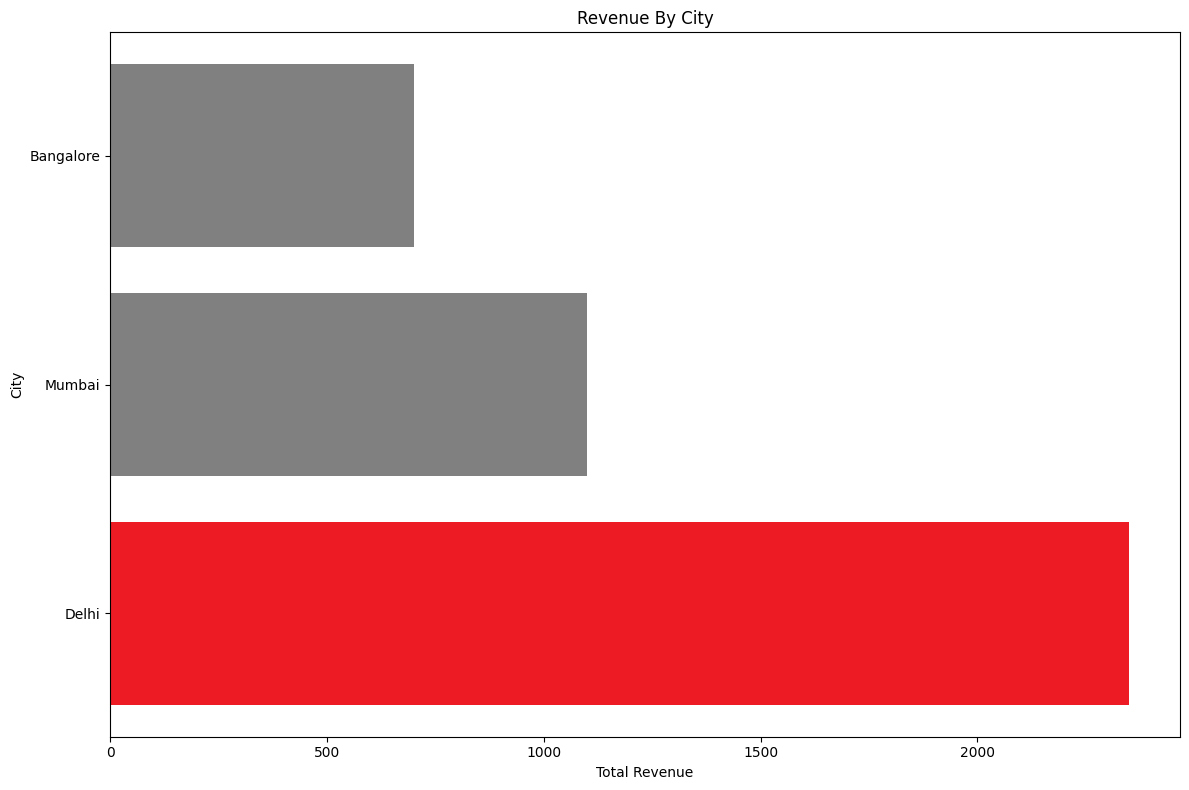

In [22]:
## Using Matplotlib OO interface, create a horizontal bar chart showing total revenue by city. Color the highest revenue city in Masai Red (#ED1C24) and others in gray. Include title "Revenue by City" and axis labels. (3 marks)
fig, ax = plt.subplots(figsize=(12, 8))
idx_max = analysis_per_city['total_revenue'].argmax()
colors = ['#ED1C24' if i ==idx_max else 'gray' for i in range(analysis_per_city.shape[0])]
ax.barh(analysis_per_city['city'], analysis_per_city['total_revenue'], color=colors)

ax.set_xlabel("Total Revenue")
ax.set_ylabel("City")
ax.set_title("Revenue By City")

fig.tight_layout()
plt.show()

  transaction_id store_id product_id  quantity        date       city region  \
0            T01       S1         P1         5  2024-01-15     Mumbai   West   
1            T02       S2         P2         3  2024-01-16      Delhi  North   
2            T03       S1         P3         2  2024-01-15     Mumbai   West   
3            T04       S3         P1         4  2024-01-17  Bangalore  South   
4            T05       S2         P2         6  2024-01-16      Delhi  North   

  product_name  price  revenue  
0     Widget A    100      500  
1     Widget B    150      450  
2     Widget C    200      400  
3     Widget A    100      400  
4     Widget B    150      900  
(8, 10)
        city  total_revenue  average_quantity
0      Delhi           2350          4.666667
1     Mumbai           1100          2.666667
2  Bangalore            700          3.500000
product_name region  Widget A  Widget B  Widget C
0             North         0      1350      1000
1             South       700

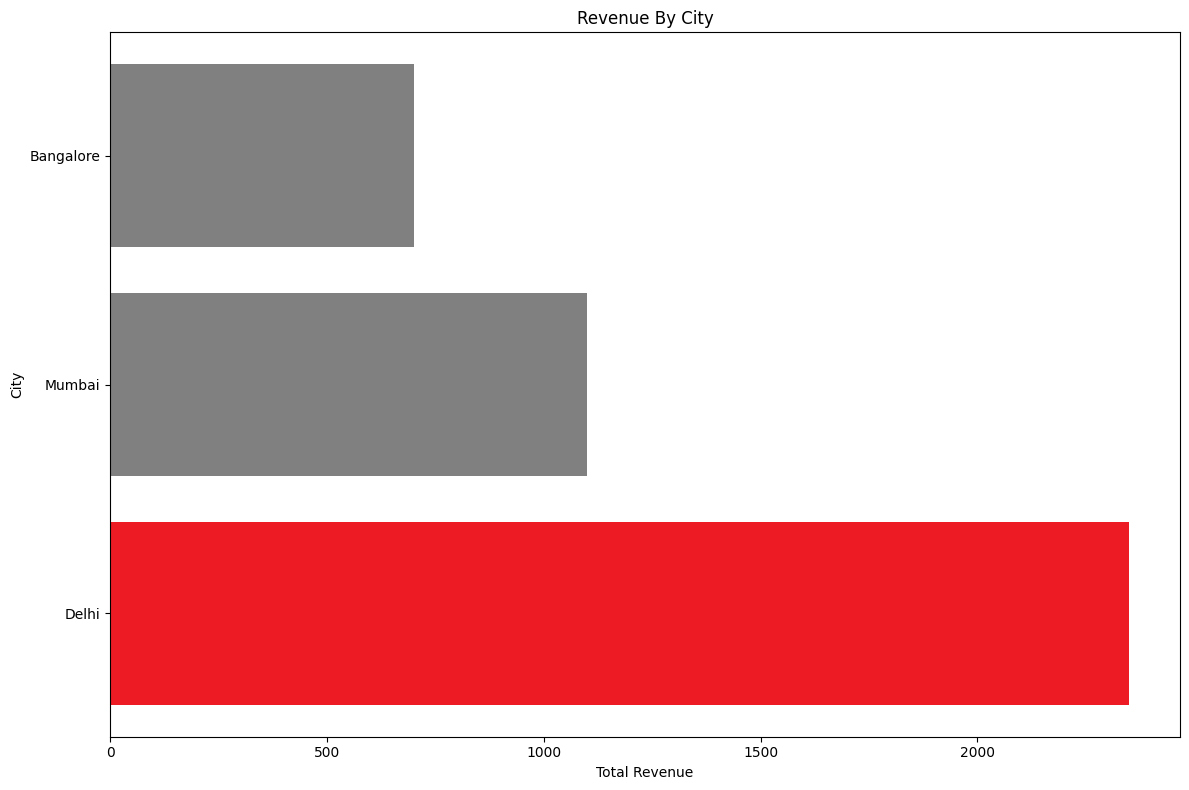

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

transactions = pd.DataFrame({
    'transaction_id': ['T01','T02','T03','T04','T05','T06','T07','T08'],
    'store_id': ['S1','S2','S1','S3','S2','S1','S3','S2'],
    'product_id': ['P1','P2','P3','P1','P2','P3','P1','P3'],
    'quantity': [5, 3, 2, 4, 6, 1, 3, 5],
    'date': ['2024-01-15','2024-01-16','2024-01-15','2024-01-17',
             '2024-01-16','2024-01-18','2024-01-17','2024-01-18']
})

stores = pd.DataFrame({
    'store_id': ['S1','S2','S3','S4'],
    'city': ['Mumbai','Delhi','Bangalore','Chennai'],
    'region': ['West','North','South','South']
})


products = pd.DataFrame({
    'product_id': ['P1','P2','P3'],
    'product_name': ['Widget A','Widget B','Widget C'],
    'price': [100, 150, 200]
})

## Merge transactions with stores (left join) and then with products (left join) to create a complete sales report. Add a revenue column (quantity × price). Print first 5 rows and shape.

sales_report = pd.merge(
    pd.merge(
        transactions, stores, on='store_id', how='left'
    ), products, on='product_id', how='inner'
)
sales_report['revenue'] = sales_report['quantity'] * sales_report['price']
print(sales_report.head())
print(sales_report.shape)

## Create a summary using groupby: Calculate total revenue and average quantity per city. Sort by total revenue descending. Print the result

analysis_per_city = sales_report.groupby('city').agg(
    total_revenue = ('revenue', 'sum'),
    average_quantity = ('quantity', 'mean')
).sort_values('total_revenue', ascending=False).reset_index()
print(analysis_per_city)

## Create a pivot table with region as rows, product_name as columns, and total revenue as values (use aggfunc='sum' and fill_value=0). Print the pivot table.

sales_report_pivot = sales_report.pivot_table(
    index = 'region', columns = 'product_name', values = 'revenue', aggfunc = 'sum', fill_value=0
).reset_index()
print(sales_report_pivot)

## Using Matplotlib OO interface, create a horizontal bar chart showing total revenue by city. Color the highest revenue city in Masai Red (#ED1C24) and others in gray. Include title "Revenue by City" and axis labels. (3 marks)
fig, ax = plt.subplots(figsize=(12, 8))
idx_max = analysis_per_city['total_revenue'].argmax()
colors = ['#ED1C24' if i ==idx_max else 'gray' for i in range(analysis_per_city.shape[0])]
ax.barh(analysis_per_city['city'], analysis_per_city['total_revenue'], color=colors)

ax.set_xlabel("Total Revenue")
ax.set_ylabel("City")
ax.set_title("Revenue By City")

fig.tight_layout()
plt.show()

##  Interpret your results: Which region generates the most revenue? Which product is the best seller? Write 2-3 sentences.

# - North region generates the most revenue.
# - Widget C is the best-selling product, generating the highest total revenue of 1600 across the West and North regions.





